In [2]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

GDP_PATH = "/Users/tonytony/Final Project/Data/Raw/gdp.csv"
LIFE_PATH = "/Users/tonytony/Final Project/Data/Raw/life_expectancy.csv"
POP_PATH = "/Users/tonytony/Final Project/Data/Raw/population.csv"
META_PATH = "/Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv"




In [3]:
meta_df = pd.read_csv(META_PATH)

region_map = meta_df[[
    "Country Code",
    "World Bank Region"
]].copy().rename(columns={
    "Country Code": "country_code",
    "World Bank Region": "wb_region"
})

region_map["country_type"] = np.where(
    region_map["wb_region"].astype(str).str.strip().eq("Aggregates"),
    "Aggregate",
    "Country/Territory"
)

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    year_cols = [col for col in df.columns if str(col).isdigit()]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    return df

def to_long(df, value_name):
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name="year",
        value_name=value_name
    ).rename(columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    })

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("int64")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

def add_region_info(long_df):
    merged = long_df.merge(region_map, on="country_code", how="left")
    merged = merged[merged["country_type"] == "Country/Territory"].copy()
    return merged

print("Helper functions are ready")


Helper functions are ready


In [4]:
gdp_long = add_region_info(to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"))
life_long = add_region_info(to_long(load_wdi(LIFE_PATH), "life_expectancy_years"))
pop_long = add_region_info(to_long(load_wdi(POP_PATH), "population_total"))

gdp_long = gdp_long[(gdp_long["gdp_per_capita_usd"].notna()) & (gdp_long["gdp_per_capita_usd"] > 0)].copy()
life_long = life_long[life_long["life_expectancy_years"].notna()].copy()
pop_long = pop_long[(pop_long["population_total"].notna()) & (pop_long["population_total"] > 0)].copy()

print("GDP latest year:", int(gdp_long["year"].max()))
print("Life latest year:", int(life_long["year"].max()))
print("Population latest year:", int(pop_long["year"].max()))


GDP latest year: 2024
Life latest year: 2023
Population latest year: 2024


In [5]:
forecast_plan = pd.DataFrame({
    "Dataset": ["GDP", "Life Expectancy", "Population"],
    "Baseline Model": ["Naive", "Naive", "Naive"],
    "Main Model": ["ARIMA(1,1,1)", "Holt Linear Trend", "Holt Trend on log(population)"],
    "Optional Model": ["AutoReg(lags=3)", "AutoReg(lags=3)", "AutoReg(lags=3)"],
    "Why": [
        "GDP is more volatile and shock-sensitive, so ARIMA is the main forecasting model.",
        "Life expectancy follows a relatively smooth long-run upward trend, so Holt trend is appropriate.",
        "Population is highly persistent and smooth, so trend-based forecasting on log scale is appropriate."
    ]
})

forecast_plan


,Dataset,Baseline Model,Main Model,Optional Model,Why
0,GDP,Naive,"ARIMA(1,1,1)",AutoReg(lags=3),"GDP is more volatile and shock-sensitive, so A..."
1,Life Expectancy,Naive,Holt Linear Trend,AutoReg(lags=3),Life expectancy follows a relatively smooth lo...
2,Population,Naive,Holt Trend on log(population),AutoReg(lags=3),"Population is highly persistent and smooth, so..."


In [6]:
forecast_horizon = 5

print("Future forecast horizon:", forecast_horizon, "years")


Future forecast horizon: 5 years


In [7]:
def forecast_country_series(series, model_name, forecast_horizon, lags=3):
    series = pd.Series(series).dropna().astype(float)

    if model_name == "Naive":
        last_value = series.iloc[-1]
        return np.repeat(last_value, forecast_horizon)

    elif model_name == "AutoReg":
        fit = AutoReg(series, lags=lags, old_names=False, trend="c").fit()
        fc = fit.predict(start=len(series), end=len(series) + forecast_horizon - 1)
        return np.asarray(fc, dtype=float)

    elif model_name == "ARIMA":
        fit = ARIMA(
            series,
            order=(1, 1, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()
        fc = fit.forecast(steps=forecast_horizon)
        return np.asarray(fc, dtype=float)

    elif model_name == "Holt":
        fit = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            damped_trend=False
        ).fit()
        fc = fit.forecast(forecast_horizon)
        return np.asarray(fc, dtype=float)

    elif model_name == "LogHolt":
        log_series = np.log(series)
        fit = ExponentialSmoothing(
            log_series,
            trend="add",
            seasonal=None,
            damped_trend=False
        ).fit()
        fc = fit.forecast(forecast_horizon)
        return np.exp(np.asarray(fc, dtype=float))

    else:
        raise ValueError(f"Unknown model: {model_name}")

def forecast_dataset(
    long_df,
    value_col,
    dataset_name,
    models_to_use,
    forecast_horizon,
    min_obs=20
):
    output_rows = []
    skipped_rows = []

    for country_code, group in long_df.groupby("country_code"):
        group = group.sort_values("year").copy()
        country_name = group["country_name"].iloc[0]
        wb_region = group["wb_region"].iloc[0]

        series = group[value_col].dropna().astype(float)

        if len(series) < min_obs:
            skipped_rows.append({
                "Dataset": dataset_name,
                "country_code": country_code,
                "country_name": country_name,
                "reason": "too_few_observations"
            })
            continue

        last_year = int(group["year"].max())
        future_years = list(range(last_year + 1, last_year + forecast_horizon + 1))

        for model_name in models_to_use:
            try:
                fc_values = forecast_country_series(
                    series=series,
                    model_name=model_name,
                    forecast_horizon=forecast_horizon
                )

                temp = pd.DataFrame({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "country_code": country_code,
                    "country_name": country_name,
                    "wb_region": wb_region,
                    "forecast_year": future_years,
                    "predicted_value": fc_values
                })

                output_rows.append(temp)

            except Exception as e:
                skipped_rows.append({
                    "Dataset": dataset_name,
                    "country_code": country_code,
                    "country_name": country_name,
                    "reason": f"{model_name}: {str(e)}"
                })

    forecast_df = pd.concat(output_rows, ignore_index=True) if output_rows else pd.DataFrame()
    skipped_df = pd.DataFrame(skipped_rows)

    return forecast_df, skipped_df

print("Forecast functions are ready")


Forecast functions are ready


In [12]:
gdp_future_forecast, gdp_future_skipped = forecast_dataset(
    long_df=gdp_long,
    value_col="gdp_per_capita_usd",
    dataset_name="GDP",
    models_to_use=["Naive", "AutoReg", "ARIMA"],
    forecast_horizon=forecast_horizon,
    min_obs=20
)

print("GDP future forecast shape:", gdp_future_forecast.shape)
print("GDP skipped rows:", gdp_future_skipped.shape[0])

gdp_future_forecast.head(15)


GDP future forecast shape: (3135, 7)
GDP skipped rows: 5


,Dataset,Model,country_code,country_name,wb_region,forecast_year,predicted_value
0,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2025,39498.594129
1,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2026,39498.594129
2,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2027,39498.594129
3,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2028,39498.594129
4,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2029,39498.594129
5,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2025,39634.453415
6,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2026,39597.720451
7,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2027,40158.245085
8,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2028,40793.301909
9,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2029,41324.660407


In [9]:
life_future_forecast, life_future_skipped = forecast_dataset(
    long_df=life_long,
    value_col="life_expectancy_years",
    dataset_name="Life Expectancy",
    models_to_use=["Naive", "AutoReg", "Holt"],
    forecast_horizon=forecast_horizon,
    min_obs=20
)

print("Life future forecast shape:", life_future_forecast.shape)
print("Life skipped rows:", life_future_skipped.shape[0])

life_future_forecast.head(15)


Life future forecast shape: (3255, 7)
Life skipped rows: 0


,Dataset,Model,country_code,country_name,wb_region,forecast_year,predicted_value
0,Life Expectancy,Naive,ABW,Aruba,Latin America & Caribbean,2024,76.353000
1,Life Expectancy,Naive,ABW,Aruba,Latin America & Caribbean,2025,76.353000
2,Life Expectancy,Naive,ABW,Aruba,Latin America & Caribbean,2026,76.353000
3,Life Expectancy,Naive,ABW,Aruba,Latin America & Caribbean,2027,76.353000
4,Life Expectancy,Naive,ABW,Aruba,Latin America & Caribbean,2028,76.353000
5,Life Expectancy,AutoReg,ABW,Aruba,Latin America & Caribbean,2024,74.689168
6,Life Expectancy,AutoReg,ABW,Aruba,Latin America & Caribbean,2025,75.426915
7,Life Expectancy,AutoReg,ABW,Aruba,Latin America & Caribbean,2026,76.292540
8,Life Expectancy,AutoReg,ABW,Aruba,Latin America & Caribbean,2027,75.508594
9,Life Expectancy,AutoReg,ABW,Aruba,Latin America & Caribbean,2028,75.361458


In [13]:
pop_future_forecast, pop_future_skipped = forecast_dataset(
    long_df=pop_long,
    value_col="population_total",
    dataset_name="Population",
    models_to_use=["Naive", "AutoReg", "LogHolt"],
    forecast_horizon=forecast_horizon,
    min_obs=20
)

print("Population future forecast shape:", pop_future_forecast.shape)
print("Population skipped rows:", pop_future_skipped.shape[0])

pop_future_forecast.head(15)


Population future forecast shape: (3255, 7)
Population skipped rows: 0


,Dataset,Model,country_code,country_name,wb_region,forecast_year,predicted_value
0,Population,Naive,ABW,Aruba,Latin America & Caribbean,2025,107995.000000
1,Population,Naive,ABW,Aruba,Latin America & Caribbean,2026,107995.000000
2,Population,Naive,ABW,Aruba,Latin America & Caribbean,2027,107995.000000
3,Population,Naive,ABW,Aruba,Latin America & Caribbean,2028,107995.000000
4,Population,Naive,ABW,Aruba,Latin America & Caribbean,2029,107995.000000
5,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,2025,108829.951556
6,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,2026,109699.534901
7,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,2027,110543.042218
8,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,2028,111344.873723
9,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,2029,112107.044627


In [14]:
all_future_forecasts = pd.concat([
    gdp_future_forecast,
    life_future_forecast,
    pop_future_forecast
], ignore_index=True)

all_future_forecasts.head(20)


,Dataset,Model,country_code,country_name,wb_region,forecast_year,predicted_value
0,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2025,39498.594129
1,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2026,39498.594129
2,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2027,39498.594129
3,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2028,39498.594129
4,GDP,Naive,ABW,Aruba,Latin America & Caribbean,2029,39498.594129
5,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2025,39634.453415
6,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2026,39597.720451
7,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2027,40158.245085
8,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2028,40793.301909
9,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,2029,41324.660407


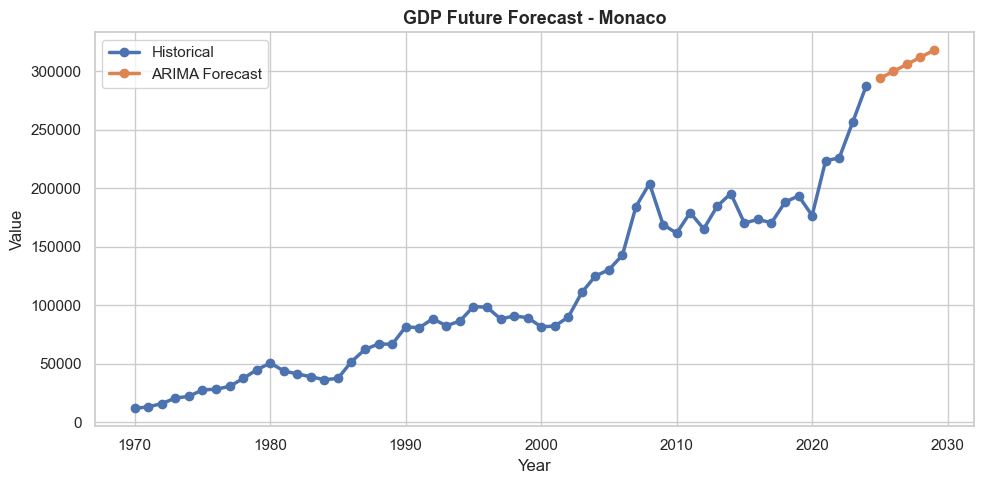

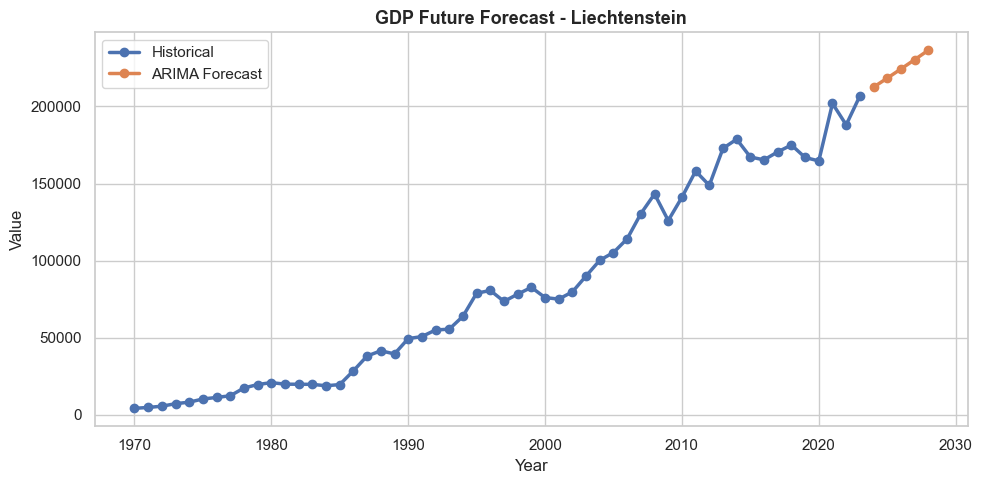

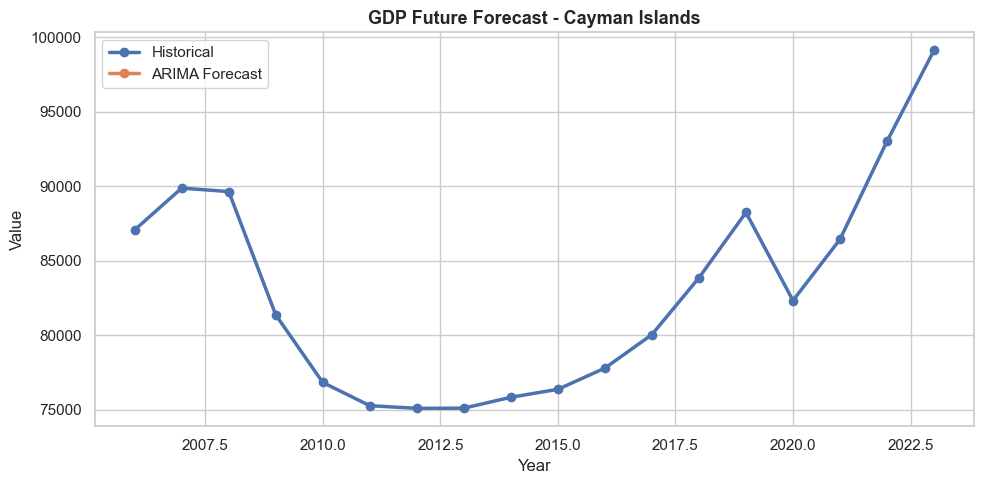

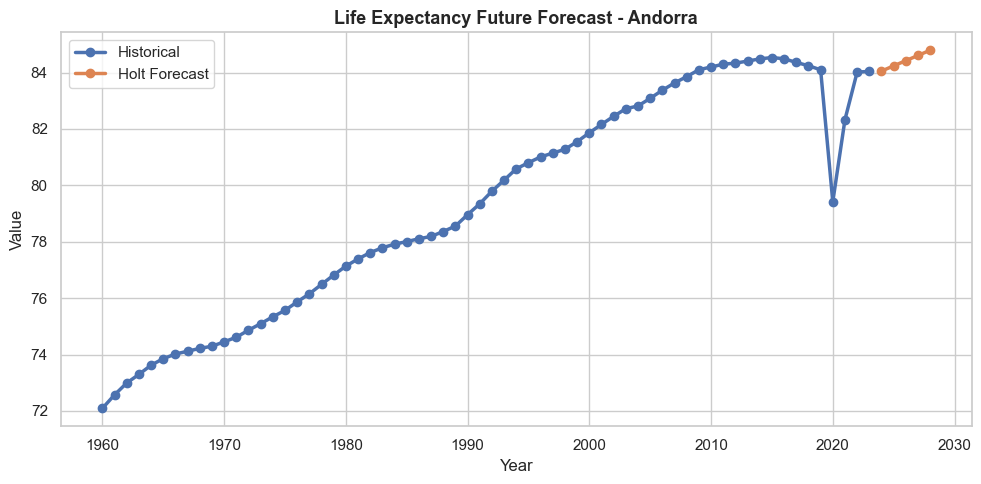

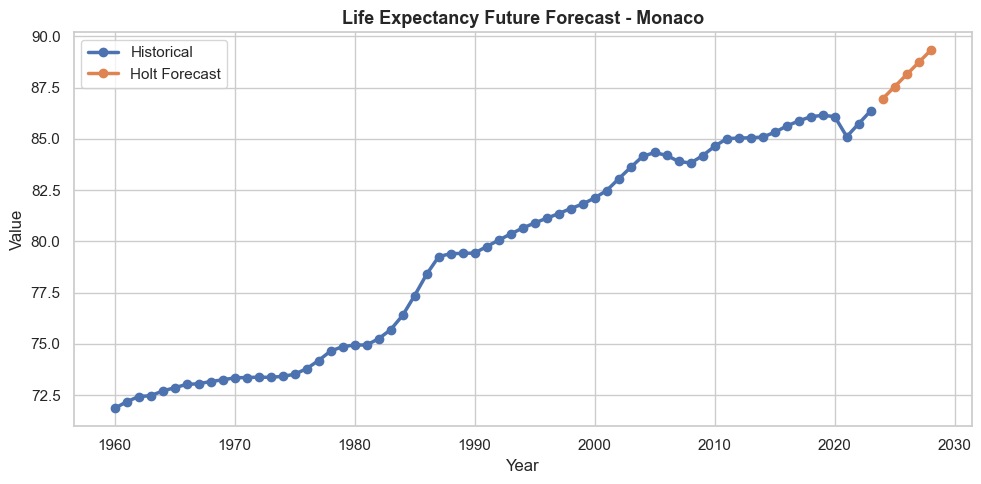

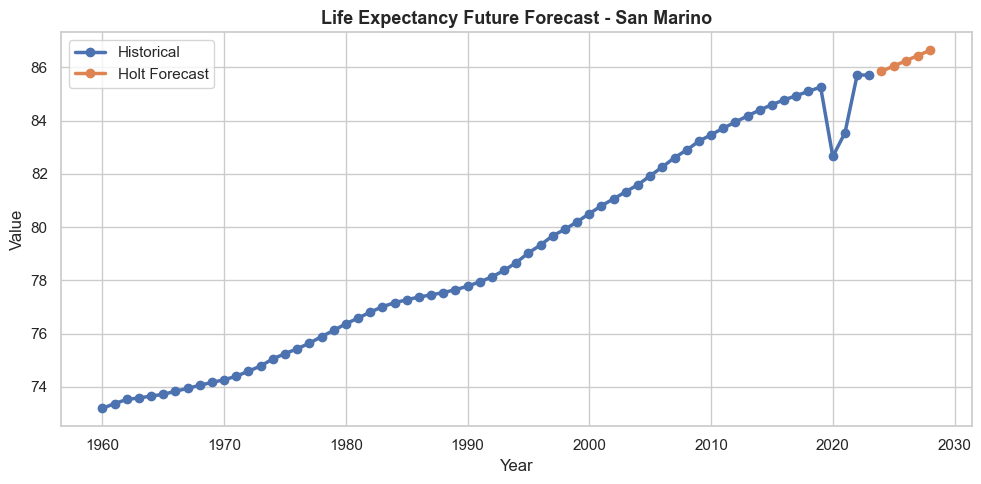

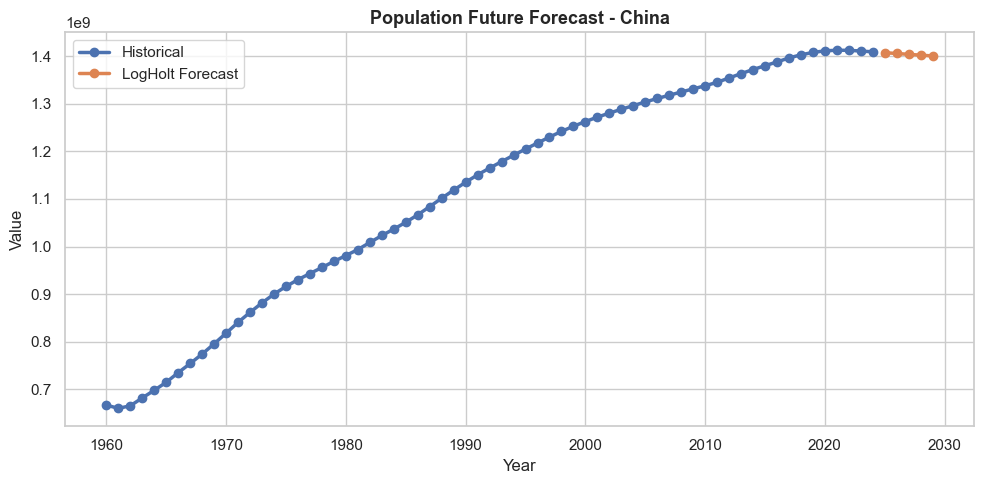

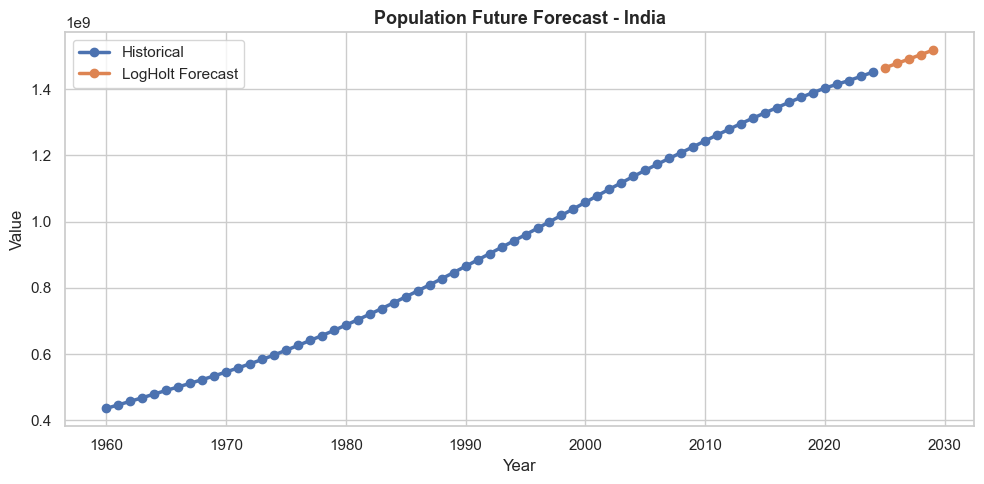

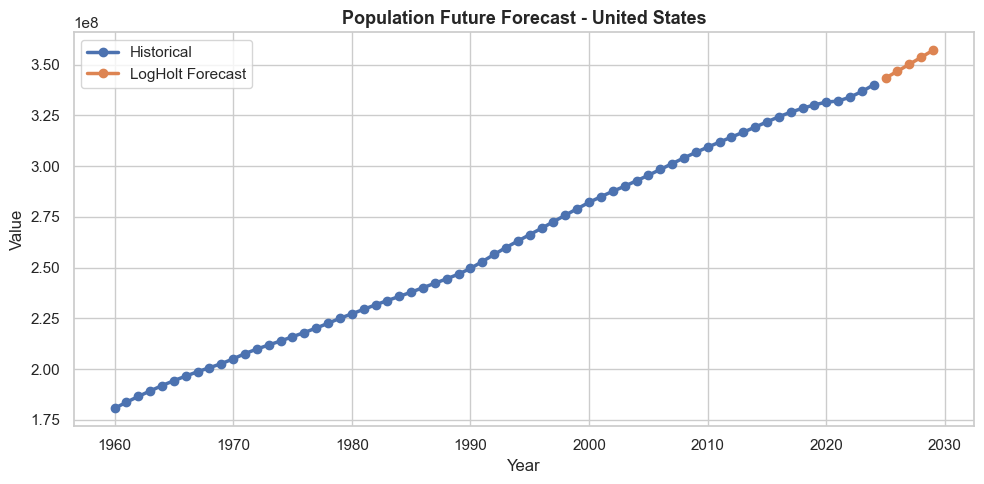

In [15]:
def plot_future_forecast_examples(long_df, forecast_df, value_col, dataset_name, model_to_show, top_n=3):
    sample_countries = (
        long_df.groupby(["country_code", "country_name"])[value_col]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    for _, row in sample_countries.iterrows():
        code = row["country_code"]
        name = row["country_name"]

        hist = long_df[long_df["country_code"] == code].sort_values("year")
        fc = forecast_df[
            (forecast_df["country_code"] == code) &
            (forecast_df["Model"] == model_to_show)
        ].sort_values("forecast_year")

        plt.figure(figsize=(10, 5))
        plt.plot(hist["year"], hist[value_col], marker="o", linewidth=2.5, label="Historical")
        plt.plot(fc["forecast_year"], fc["predicted_value"], marker="o", linewidth=2.5, label=f"{model_to_show} Forecast")

        plt.title(f"{dataset_name} Future Forecast - {name}", fontsize=13, fontweight="bold")
        plt.xlabel("Year")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_future_forecast_examples(gdp_long, gdp_future_forecast, "gdp_per_capita_usd", "GDP", "ARIMA", top_n=3)
plot_future_forecast_examples(life_long, life_future_forecast, "life_expectancy_years", "Life Expectancy", "Holt", top_n=3)
plot_future_forecast_examples(pop_long, pop_future_forecast, "population_total", "Population", "LogHolt", top_n=3)
